# Gridsearch Comparison Plots

This notebook loads `combined_comparison_summary_long.tsv` and plots metrics from your gridsearch runs.

Default focus is gene `ENSSSCT00000000003` (rows where that gene is present in the table).

In [3]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

In [31]:
# Paths and options
input_path = Path("../../testFiles/gridsearch4_dna/combined_comparison_summary_long.tsv")
# If needed, change to None to use all genes
gene_of_interest = "ENSSSCT00000000003"
output_dir = Path("../../testFiles/gridsearch4_dna/plots_notebook")
output_dir.mkdir(parents=True, exist_ok=True)

if not input_path.exists():
    alt = Path("testFiles/gridsearch4/combined_comparison_long.tsv")
    if alt.exists():
        input_path = alt
    else:
        raise FileNotFoundError(f"Input TSV not found: {input_path}")

input_path

PosixPath('../../testFiles/gridsearch4_dna/combined_comparison_summary_long.tsv')

In [32]:
# Load and validate
required_columns = {
    "k",
    "offset",
    "threshold",
    "gene",
    "filtered_reads",
    "mapping_reads",
    "matched",
    "not_mapped",
    "not_filtered",
}

df = pd.read_csv(input_path, sep="\t")
missing = required_columns - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {sorted(missing)}")

numeric_cols = [
    "k",
    "offset",
    "threshold",
    "filtered_reads",
    "mapping_reads",
    "matched",
    "not_mapped",
    "not_filtered",
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

if df[numeric_cols].isna().any().any():
    bad = df[numeric_cols].isna().sum()
    raise ValueError(f"Non-numeric values found in numeric columns:\n{bad[bad > 0]}")

df["precision"] = df["matched"] / df["filtered_reads"].replace(0, pd.NA)
df["recall"] = df["matched"] / df["mapping_reads"].replace(0, pd.NA)

df.head()

,k,offset,threshold,gene,filtered_reads,mapping_reads,matched,not_mapped,not_filtered,summary_file,precision,recall
0,12,12,36,ENSSSCG00000000002,486827,67,67,486760,0,k_12/offset_12/threshold_36/comparison_summary...,0.000138,1.000000
1,12,12,36,ENSSSCG00000000906,3128658,483,477,3128181,6,k_12/offset_12/threshold_36/comparison_summary...,0.000152,0.987578
2,12,12,36,ENSSSCG00000002245,2313177,420,415,2312762,5,k_12/offset_12/threshold_36/comparison_summary...,0.000179,0.988095
3,12,12,36,ENSSSCG00000011316,746368,616,608,745760,8,k_12/offset_12/threshold_36/comparison_summary...,0.000815,0.987013
4,12,12,36,ENSSSCG00000015652,20932,80,80,20852,0,k_12/offset_12/threshold_36/comparison_summary...,0.003822,1.000000


In [10]:
# Optional gene filter
plot_df = df.copy()
if gene_of_interest is not None:
    plot_df = plot_df[plot_df["gene"] == gene_of_interest]

if plot_df.empty:
    raise ValueError(f"No rows found for gene filter: {gene_of_interest}")

print(f"Rows used for plotting: {len(plot_df)}")
print("Genes in plot_df:", sorted(plot_df["gene"].unique()))

Rows used for plotting: 29
Genes in plot_df: ['ENSSSCT00000000003']



## Plot 1: Matched reads vs threshold

In [34]:
df.sort_values("recall", ascending=False)

df.loc[df.groupby("gene")["recall"].idxmax(), 
       ["gene", "k", "offset", "threshold", "recall", "precision"]]



,gene,k,offset,threshold,recall,precision
0,ENSSSCG00000000002,12,12,36,1.000000,0.000138
1,ENSSSCG00000000906,12,12,36,0.987578,0.000152
2,ENSSSCG00000002245,12,12,36,0.988095,0.000179
3,ENSSSCG00000011316,12,12,36,0.987013,0.000815
4,ENSSSCG00000015652,12,12,36,1.000000,0.003822
5,ENSSSCG00000044511,12,12,36,0.000000,<NA>


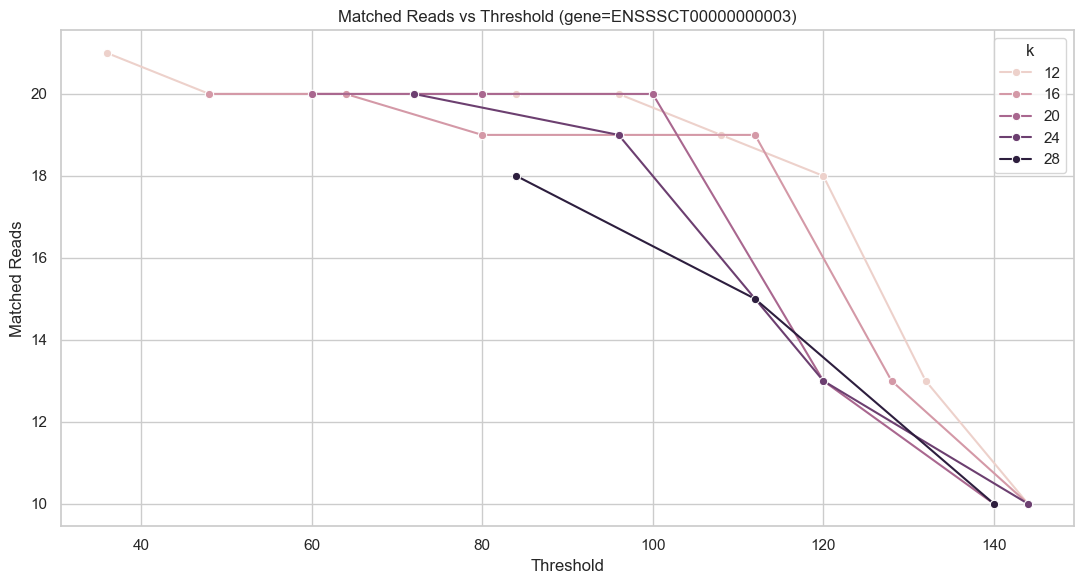

PosixPath('../../testFiles/gridsearch4/plots_notebook/matched_vs_threshold.png')

In [15]:
plt.figure(figsize=(11, 6))
sns.lineplot(
    data=plot_df,
    x="threshold",
    y="matched",
    hue="k",
    marker="o",
)
title_suffix = f" (gene={gene_of_interest})" if gene_of_interest else ""
plt.title(f"Matched Reads vs Threshold{title_suffix}")
plt.xlabel("Threshold")
plt.ylabel("Matched Reads")
plt.tight_layout()
out1 = output_dir / "matched_vs_threshold.png"
plt.savefig(out1, dpi=200)
plt.show()
out1

## Plot 2: Precision and recall vs threshold

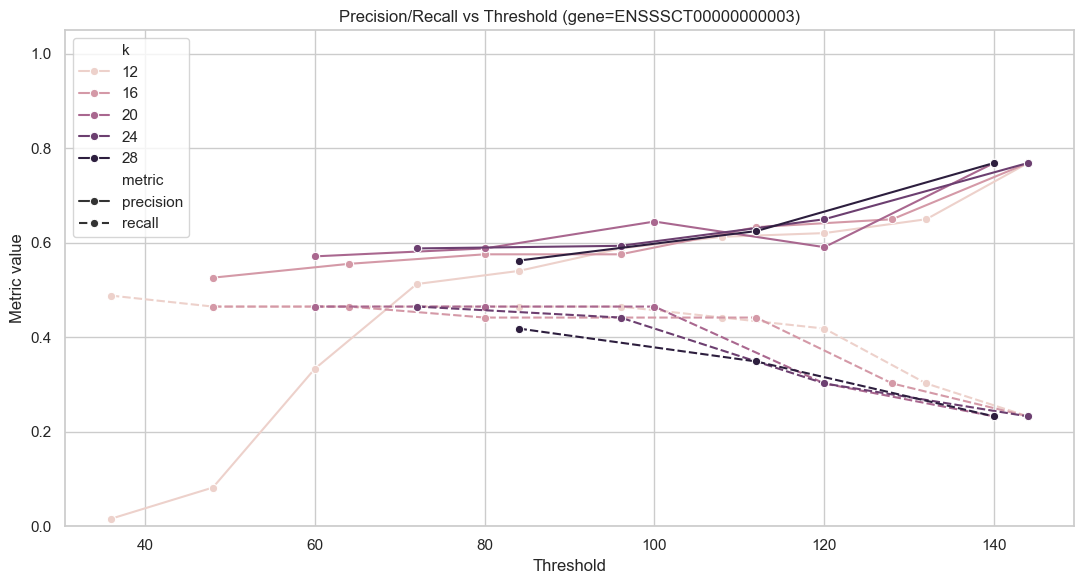

PosixPath('../../testFiles/gridsearch4/plots_notebook/precision_recall_vs_threshold.png')

In [16]:
melted = plot_df.melt(
    id_vars=["k", "threshold", "gene"],
    value_vars=["precision", "recall"],
    var_name="metric",
    value_name="value",
)

plt.figure(figsize=(11, 6))
sns.lineplot(
    data=melted,
    x="threshold",
    y="value",
    hue="k",
    style="metric",
    marker="o",
)
plt.title(f"Precision/Recall vs Threshold{title_suffix}")
plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.ylim(0, 1.05)
plt.tight_layout()
out2 = output_dir / "precision_recall_vs_threshold.png"
plt.savefig(out2, dpi=200)
plt.show()
out2

## Plot 3: Heatmap of matched reads (k × threshold)

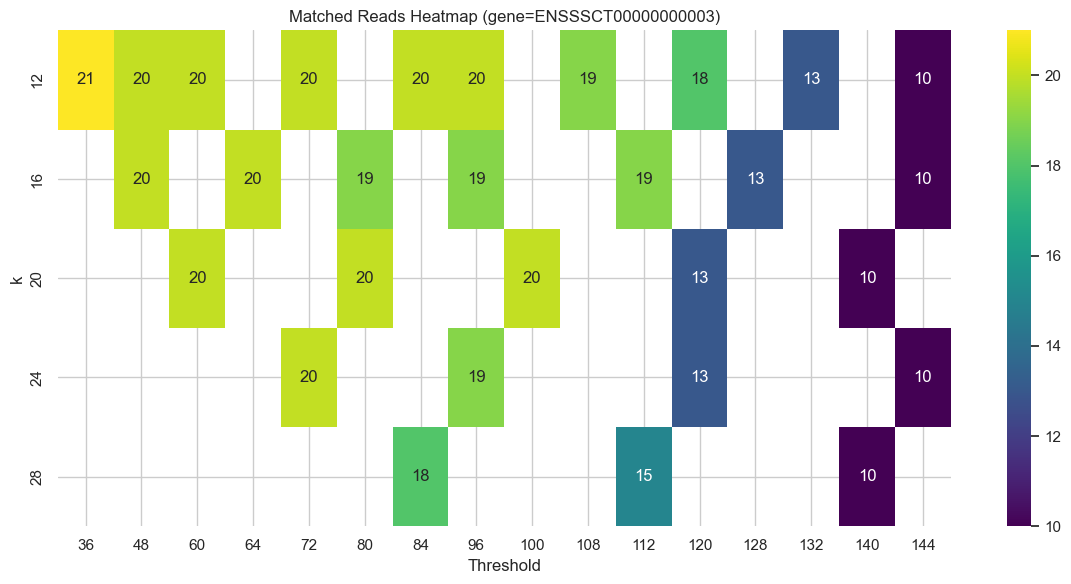

PosixPath('../../testFiles/gridsearch4/plots_notebook/matched_heatmap_ENSSSCT00000000003.png')

In [17]:
heatmap_source = plot_df if gene_of_interest else df

if gene_of_interest:
    hm_df = heatmap_source
else:
    # If multiple genes are present and no filter is selected, use averages over genes
    hm_df = heatmap_source.groupby(["k", "threshold"], as_index=False)["matched"].mean()

pivot = hm_df.pivot_table(index="k", columns="threshold", values="matched", aggfunc="mean").sort_index()

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="viridis")
heat_title = f"Matched Reads Heatmap (gene={gene_of_interest})" if gene_of_interest else "Matched Reads Heatmap (mean across genes)"
plt.title(heat_title)
plt.xlabel("Threshold")
plt.ylabel("k")
plt.tight_layout()
safe_gene = (gene_of_interest or "all_genes").replace("/", "_")
out3 = output_dir / f"matched_heatmap_{safe_gene}.png"
plt.savefig(out3, dpi=200)
plt.show()
out3

In [ ]:
print("Saved plot files:")
for p in [out1, out2, out3]:
    print(p)